## Introduction

This notebook was originally created to generate a base dataset for the [Google - Gemini Long Context competition](https://www.kaggle.com/competitions/gemini-long-context/overview)

**Author: Mateusz Dobrychlop [(Linkedin)](https://www.linkedin.com/in/mdobrychlop/)**

This notebook leverages Google's Gemini large language models (gemini-1.5-flash by default) to generate a potentially large, synthetic dataset that simulates a set of a single person's daily personal records, that include to-do lists, journal entries, and various personal notes.

The daily records follow a consistent, completely synthetic story that can span and progress over the course of many months or even years. The records include content related to the person's work and family life, and take into account details such as goals, habits, and personal development.



## Summary of the methodology

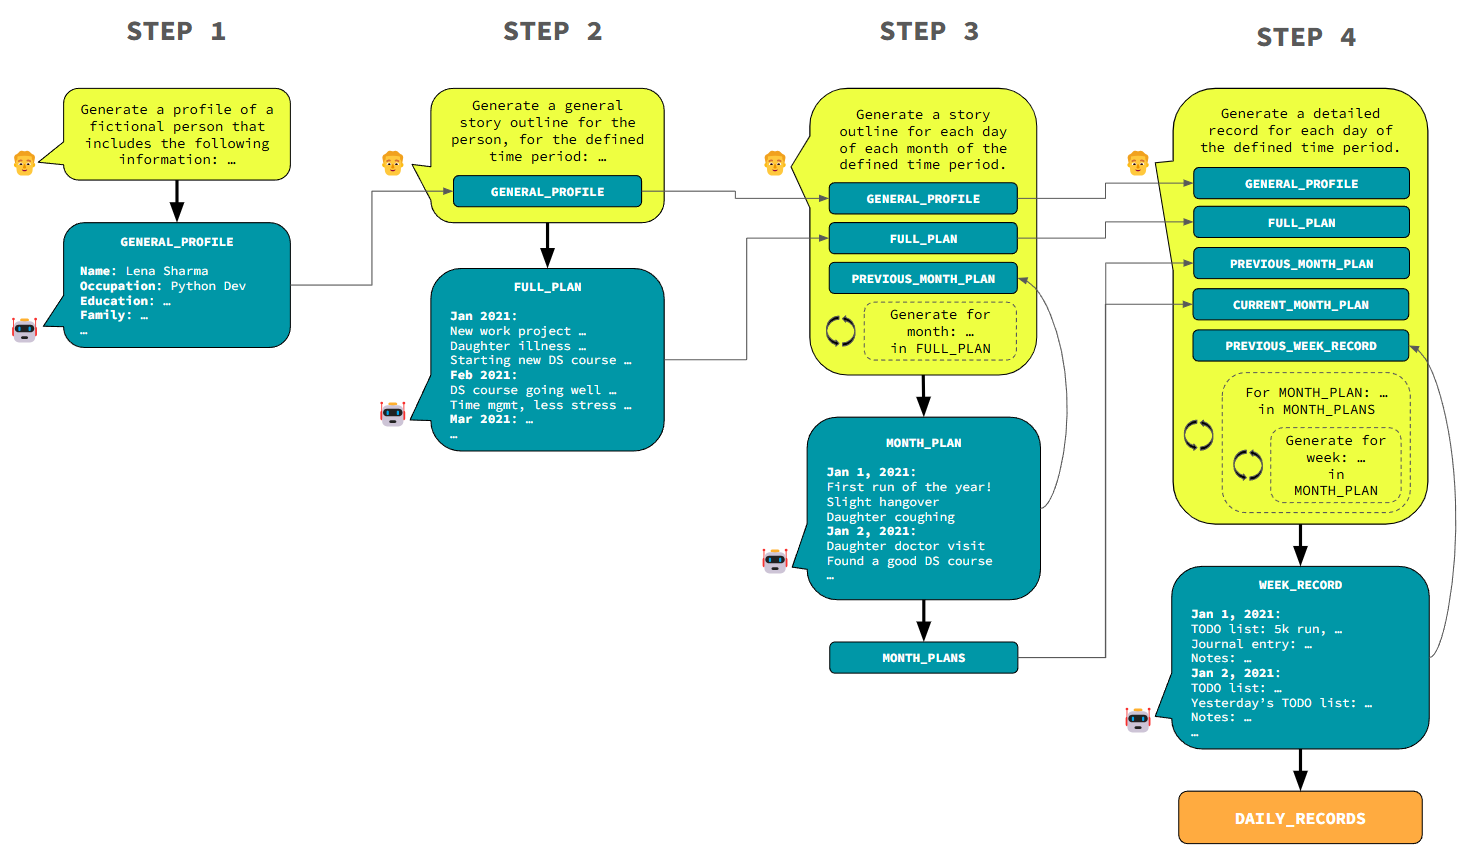

### STEP 1: Generation of the person's general profile

The procedure starts with generating a synthetic profile for the person. The information included in the profile includes:

- Name
- Age
- Occupation
- Employment history (including fictional company names)
- Education history
- Family situation (including names of family members)
- Fitness habits
- 2 education / self-development goals
- 2 fitness / health related goals
- 2 hobbies
- 2 positive traits
- 2 negative traits
- 1 habit that the person is trying to get rid of
- 1 habit that the person is trying to adopt

### STEP 2: Genreation of the full plan for the defined time period

When the profile is ready, it is then used as a basis to generate a general outline of the story for the entire time period defined by the user. This full plan includes a list of bullet points for each month of the defined period, that will guide the overall development of the story. The entire full plan is generated in a single completion based on a set of instructions and the attached general profile.

### STEP 3: Generation of daily outlines for each month of the defined time period

Looping through the list of months in the defined time period, the language model is prompted to generate a list of events for every day of each month. The monthly plans are stored in a collective list, to be used to generate final daily records in the final step. The context used to generate each monthly plan includes a set of instructions, the general profile, the full plan for the entire period, and (if applicable) the monthly plan generated for the previous month in the previous iteration of the loop.

### STEP 4: Gneration of detailed daily records

In the final step, the algorithm loops through the list of monthly plans generated in STEP 3. Each month is then divided into chunks, each approximately corresponding to a single week. For each chunk, detailed daily records are generated. Each record contains the following components:

- a to-do list for the day
- the previous day's to-do list with an indication of completed tasks
- a short journal entry
- a list of various notes and reminders

The context used to generate each weekly set of daily records includes a set of instructions, the general profile, the full plan, daily outlines for both the currently processed month and the previous month, and (if applicable) the daily records from the previous week.

The resulting full dataset contains detailed daily records for each day of the time period defined in STEP 2.

The full dataset is saved as a json file, where the daily records are preceeded by the general profile. Each daily record is represented by a key that contains a date, and a value that contains unstructured content of the record. This simple structure is sufficient for further processing by a large language model. The example below illustrates the structure of the resulting json file:

```json
{
    "GENERAL_PROFILE": {
        "name": "Liam Anderson",
        "age": 32,
        "details": "* Occupation: Python Developer\n* Employment History:  CodeSmith Technologies (2019-Present), WebLogic Solutions (2016-2019), TechNexus (2014-2016)\n* Education History: Master's Degree in Software Engineering,  Technion University; Bachelor's Degree in Computer Science,  Innovation University\n* Family: Wife:  Emily, Son:  Lucas (4 years old), Daughter:  Ava (2 years old)\n* Fitness Habits: Weightlifting (4 times a week), Running (3 times a week)\n* Education/Self-Development Goals: Learn Data Science, Improve Time Management Skills\n* Fitness/Health Goals:  Run a Half Marathon, Improve Diet\n* Hobbies:  Gaming, Hiking\n* Positive Traits:  Organized,  Creative\n* Negative Traits:  Overly Critical,  Introverted\n* Habit to Break:  Snacking\n* Habit to Adopt:  Meditation"
    },
    "DAILY_RECORDS": {
        "October 1, 2022": "**Tasks for Today:**\n- First run of the week.  (Completed)\n- Enrolled in the Data Science course.  (Completed)\n- Attempt to stick to a healthy snack.  (Partially Completed)\n- Discuss the pregnancy news with Emily.  (Completed)\n- Collaborative meetings for the new project.  (Completed)\n\n**Completed Yesterday:**\n- None.\n\n**Journal Entry:**\nThe cool autumn air wakes me up with a feeling of anticipation for the day ahead. The thought of finally taking steps towards my half-marathon goal motivates me. I'm excited about enrolling in the Data Science course, hoping to learn something new and exciting.  Although the news of Emily's pregnancy brings joy, I must admit that the thought of a third child makes me feel a little overwhelmed. I'm hoping to find a good balance between my work, my family, and my personal goals. \n\n**Notes:**\n- New project lead - Sarah Thompson (sarah.thompson@codesmith.com)\n- Data Science course:  DataScience.com\n- Half Marathon training plan -  RunningForLife.net",
        "October 2, 2022": "**Tasks for Today:**\n- Second run of the week.  (Completed)\n- Research Data Science course material.  (Partially Completed)\n- Stick to a healthy snack.  (Partially Completed)\n- Discuss the pregnancy news with Emily. (Completed)\n- Collaborative meetings for the new project.  (Completed)\n\n**Completed Yesterday:**\n- First run of the week.  (Completed)\n- Enrolled in the Data Science course.  (Completed)\n- Discuss the pregnancy news with Emily.  (Completed)\n- Collaborative meetings for the new project.  (Completed)\n\n**Journal Entry:**\nMy legs feel a little sore from yesterday's run, but the feeling of accomplishment keeps me going. I'm excited to dive into the Data Science course, but a sense of apprehension creeps in.  The information feels vast and overwhelming, but I'm determined to push through.  Emily's pregnancy has been a joyful surprise, and I'm feeling grateful for this blessing. I'm aware that this will be a significant change for our family, but I'm eager to welcome our newest addition. \n\n**Notes:**\n- Project kickoff meeting - tomorrow morning.\n- Team members: Sarah Thompson, Mark Williams, Anna Petrov",
        "October 3, 2022": "**Tasks for Today:**\n- Third run of the week.  (Completed)\n- Research Data Science course material.  (Partially Completed)\n- Stick to a healthy snack.  (Partially Completed)\n- Schedule doctor's appointment for Emily.  (Completed)\n- Work on the new project. (Completed)\n\n**Completed Yesterday:**\n- Second run of the week.  (Completed)\n- Research Data Science course material.  (Partially Completed)\n- Discuss the pregnancy news with Emily. (Completed)\n- Collaborative meetings for the new project.  (Completed)\n\n**Journal Entry:**\nI feel a sense of accomplishment after completing my run today, even though I'm feeling a little sore. I'm trying to find a good balance between my training for the half marathon and the workload I've taken on at work.  The new project is demanding, and I'm trying to navigate a new team with varying personalities.  Emily's pregnancy has brought a wave of joy and excitement, but I'm also feeling a bit overwhelmed.  I need to find a way to manage my time and energy effectively. \n\n**Notes:**\n- Doctor's appointment: Dr. Brown, 10/10 at 2 pm.\n- New project deadline:  November 15th\n- DataScience.com - online community forum"
    }
}
```

## Setup

### Setup the LLM machinery

In [1]:
import google.generativeai as genai
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
googleai_api_key = user_secrets.get_secret("googleai_api_key")

model = "gemini-1.5-flash"
temperature = 1.6

genai.configure(api_key=googleai_api_key)
model = genai.GenerativeModel(model, generation_config={"temperature":temperature})

### Setup functions for prompt and response processing

Currently, at least based on my experience, making an LLM consistently return a clean, JSON-formatted response is difficult and unreliable (and that's despite "JSON modes" being offered in official APIs of various LLMs). Therefore in this notebook, whenever some structuring is required, the models are prompted to format the responses using XML/HTML-like tags. This concept seems to be much easier to grasp for the models, and allows for very straightforward parsing, and ultimately reformatting into JSON if needed.

The cell below defines a toolset for processing of the LLM's responses, as well as some other useful functionalities (see comments for more information).

In [2]:
import re
import json
from io import StringIO
from calendar import month_name


def generate_raw_output(prompt, model, token_control=False):
    """
    Returining the text contents of a response, with an option to display token counts.
    """
    prompt_tokens = str(model.count_tokens(prompt)).replace("total_tokens: ", "").replace("\n", "")
    result = model.generate_content(prompt)
    result_tokens = result.usage_metadata.total_token_count
    if token_control:
        print(f"OK. Input tokens: {prompt_tokens}. Output tokens: {result_tokens}.")
    return result.text

def verify_profile_tags(content):
    """
    Verifies if all expected tags are present in a response that contains
    the general profile.
    """
    if "<name>" not in content and "</name>" not in content:
        print("Profile does not contain a name tag")
        return False
    if "<age>" not in content and "</age>" not in content:
        print("Profile does not contain an age tag")
        return False
    if "<details>" not in content and "</details>" not in content:
        print("Profile does not contain a details tag")
        return False
    return True

def verify_plan_tags_and_length(content, length):
    """
    Verifies if all expected tags are present in a response that contains
    a plan (applies to the full and monthly plans, and to daily records)
    """
    if "<record>" not in content and "</record>" not in content:
        print("Plan does not contain a record tag")
        return False
    if "<date>" not in content and "</date>" not in content:
        print("Plan does not contain a date tag")
        return False
    if "<plan>" not in content and "</plan>" not in content:
        print("Plan does not contain a plan tag")
        return False
    
    if content.count("<record>") != length:
        print(f"Plan does not contain the expected number of records (expected: {length}, actual: {content.count('<record>')})")
        return False

    return True


def parse_profile(content):
    """
    Parses the response that contains the general profile,
    and returns the information organized in a dictionary.
    """
    parsed_data = {}

    try:
        # Adjusting regex to account for possible newline and whitespace after opening tags
        name = re.search(r"<name>\s*(.*?)\s*</name>", content, re.DOTALL).group(1).strip()
        age = int(re.search(r"<age>\s*(.*?)\s*</age>", content, re.DOTALL).group(1).strip())
        details = re.search(r"<details>\s*(.*?)\s*</details>", content, re.DOTALL).group(1).strip()

        parsed_data["name"] = name
        parsed_data["age"] = age
        parsed_data["details"] = details

    except Exception as e:
        print("Error: One of the tags is missing or mismatched in the input.")
        raise e

    return parsed_data


def parse_plan(content):
    """
    Parses a plan response (full plan, monthly plan, daily records for a week),
    and returns the information organized in a dictionary.
    """
    parsed_data = {}
    
    try:
        records = re.findall(r"<record>\s*(.*?)\s*</record>", content, re.DOTALL)
        for record in records:
            date = re.search(r"<date>\s*(.*?)\s*</date>", record).group(1).strip()
            plan_items = re.search(r"<plan>\s*(.*?)\s*</plan>", record, re.DOTALL).group(1).strip()
            parsed_data[date] = plan_items

    except Exception as e:
        print("Error: One of the tags is missing or mismatched in the input.")
        raise e

    return parsed_data

def attempt_structured_output(model, prompt, type, attempts=3, plan_length=None, token_control=False):
    """
    Requeries the model until the output is correctly structured.
    """
    for attempt in range(attempts):
        result_text = generate_raw_output(prompt, model, token_control=token_control)
        if type == "profile":
            if verify_profile_tags(result_text):
                hopefully_structured_response = parse_profile(result_text)
                return hopefully_structured_response
            else:
                print(f"Attempt {attempt + 1} failed. Trying again.")
        elif type == "plan":
            if verify_plan_tags_and_length(result_text, plan_length):
                #print(result_text)
                hopefully_structured_response = parse_plan(result_text)
                #print(hopefully_structured_response)
                return hopefully_structured_response
            else:
                print(f"Attempt {attempt + 1} failed. Trying again.")

def generate_month_list(timespan_start, timespan_end):
    """
    Returns a list of months contained within a defined timespan.
    Each month is represented by a dictionary containing the name of the month and the year.
    """
    start_month = list(month_name).index(timespan_start["month"])
    start_year = int(timespan_start["year"])
    end_month = list(month_name).index(timespan_end["month"])
    end_year = int(timespan_end["year"])

    result = []

    current_year, current_month = start_year, start_month
    while (current_year < end_year) or (current_year == end_year and current_month <= end_month):
        result.append({"month": month_name[current_month], "year": current_year})

        current_month += 1
        if current_month > 12:
            current_month = 1
            current_year += 1

    return result

def verify_plan_length(plan, expected_length):
    """
    Checks if the number of records provided in a plan is equal to an expected number.
    """
    if len(plan) != expected_length:
        print(f"Plan length ({len(plan)}) does not match timespan length ({expected_length})")
        return False
    return True


## Step 1: Generate a general profile of the character

Even though the output of this step is provided as a string in subsequent steps, we still ask for a structured, Python-syntax-like output. This is to introduce some kind of discipline and at least some degree of structure for the output. For example, if we don't ask for a Python dictionary, sometimes the labels for the different positions of the profiles are missing (instead of "Name: John, Age: 30", we get "John, 30"). This could still work but is not ideal.


In [3]:
general_profile_constraints = ""  #"male, Python developer, 2 kids, lifts weights, runs"

general_profile_prompt = f"""
Create a profile of a person who does not exist. The profile should include:
- Name
- Age
- Occupation
- Employment history (including fictional company names)
- Education history
- Family situation (including names of family members)
- Fitness habits
- 2 education / self-development goals
- 2 fitness / health related goals
- 2 hobbies
- 2 positive traits
- 2 negative traits
- one habit that the person is trying to get rid of
- one habit that the person is trying to adopt

{f'The list above must adhere to the following constraints: {general_profile_constraints}' if general_profile_constraints != '' else ''}

Keep the list simple. Each element should be a single keyword or a list of keywords. 

All company names included have to be fictional. All education institutions included have to be fictional.

Output formatting:
The general profile should be formatted using 3 html tags.
Name should be included between <name> and </name> tags.
Age should be included between <age> and </age> tags.
Other details should be included between <details> and </details> tags.
The details should be a list of bullet points, each included between * and a newline character.

Example output:

<name>
Ethan Walker
</name>
<age>
35
</age>
<details>
* Occupation: Senior Python Developer
* Employment History: Greenfield Solutions (2020-Present), TechSphere Innovations (2017-2020), CodeCrafters Inc. (2014-2017)
* Education History: Master's Degree in Computer Science, Innovation University; Bachelor's Degree in Software Engineering, Tech Institute
* Family: Wife: Olivia, Son: Liam (5 years old), Daughter: Sophia (3 years old)
* Fitness Habits: Weightlifting (3 times a week), Running (4 times a week)
* Education/Self-Development Goals: Learn Machine Learning, Improve Public Speaking Skills
* Fitness/Health Goals: Run a Marathon, Improve Sleep Quality
* Hobbies: Photography, Playing Guitar
* Positive Traits: Problem-Solver, Dedicated
* Negative Traits: Impatient, Workaholic
* Habit to Break: Procrastination
* Habit to Adopt: Mindfulness
</details>

"""

GENERAL_PROFILE = attempt_structured_output(model, general_profile_prompt, "profile", token_control=True)
if GENERAL_PROFILE:
    print("General profile successfully generated.")
    print(GENERAL_PROFILE)
    profile_id = f"{GENERAL_PROFILE['name']}_{GENERAL_PROFILE['age']}"

    with open(f"GENERAL_PROFILE_{profile_id}.json", "w") as f:
        json.dump(GENERAL_PROFILE, f)


OK. Input tokens: 470. Output tokens: 688.
General profile successfully generated.
{'name': 'Seraphina Jones', 'age': 28, 'details': '* Occupation:  Marine Biologist\n* Employment History: Oceanus Research Institute (2022-Present), Coral Reef Conservation (2019-2022),  AquaLife Laboratories (2017-2019)\n* Education History: PhD Marine Biology,  Atlantic University; MSc  Ecology, Coastal University; BSc Biology, Seaview College\n* Family: Mother: Eleanor Jones, Sister:  Chloe Jones\n* Fitness Habits: Yoga, Hiking\n* Education/Self-Development Goals: Learn Spanish, Publish research paper\n* Fitness/Health Goals: Improve flexibility,  Increase cardio fitness\n* Hobbies:  Scuba Diving,  Knitting\n* Positive Traits: Empathetic,  Persistent\n* Negative Traits:  Overly critical,  Perfectionist\n* Habit to Break:  Excessive caffeine consumption\n* Habit to Adopt:  Daily meditation'}


## Step 2: Generate a very general backstory for the entire required period

In [4]:
full_timespan_start = {"month":"October", "year":"2020"}
full_timespan_end = {"month":"September", "year":"2021"}
full_timespan_length = "12 months"


months_within_full_timespan = generate_month_list(full_timespan_start, full_timespan_end)
full_timespan_context = f"{full_timespan_length}, from {full_timespan_start['month']}, {full_timespan_start['year']} to {full_timespan_end['month']}, {full_timespan_end['year']}"

# divide the months_within_timespan list into max 12-month chunks
year_chunks = [months_within_full_timespan[i:i + 12] for i in range(0, len(months_within_full_timespan), 12)]

FULL_PLAN = {}
PREVIOUS_YEAR_PLAN = None

for chunk in year_chunks:
    year_chunk_context = f"{chunk[0]['month']}, {chunk[0]['year']} to {chunk[-1]['month']}, {chunk[-1]['year']}"
    year_chunk_length = len(chunk)

    if PREVIOUS_YEAR_PLAN:
        previous_year_chunk_context = f"Here's the plan written for the previous year (it is formatted as a dictionary, but your output should be formatted using html tags as instructed further below):\n{PREVIOUS_YEAR_PLAN}\n"
    else:
        previous_year_chunk_context = ""

    year_chunk_plan_prompt = f"""
    You will be provided with a profile of a fictional person, who is a character in a story.

    Here's the character's profile (between <profile> and </profile> tags):

    <profile>
    {GENERAL_PROFILE}
    </profile>

    Your task is to assist with writing a very basic outline of a fictional backstory for the person.

    The backstory should span over the course of {year_chunk_context}.
    For each of the following sections of the character's profile:
    - Fitness / health goals
    - Education / self-development goals
    - Habits to break
    - Habits to adopt,
    come up with a simple outline of the character's progress or regress for each month of {year_chunk_context}.

    In addition, come up with:
    - one interesting plot line related to the character's family life that spans over the course of several months
    - one interesting plot line related to the character's work life that spans over the course of several months
    and also plan out how the two plot lines develop over the course of {year_chunk_length}.
    The plot lines mentioned above should be reflected in the plan itself, not mentioned separately.

    The backstory should include successes, failures, obstacles, opportunities.

    Therefore, for each month of {year_chunk_context}, provide a list of 6 keywords or very brief sentences.
    The keywords or brief sentences should represent a state or a change in the given aspect of the character's life during that month.
    Events should not only affect other events in the same month, but also in the following months.

    The backstory will be used as a backbone to write a more detailed short story later on. The backstory should be consistent and interesting.

    {previous_year_chunk_context}    

    Output formatting:
    The backstory plan should be formatted using html-tags. Content for each month should be included between <record> and </record> tags.
    Each month should have a date and a plan. The date should be included between <date> and </date> tags. The plan should be included between <plan> and </plan> tags.
    The plan should be a list of bullet points, each included between * and a newline character.

    The number of records should always match the number of months in the timespan.

    Example output for 12 months (from October 2022 to September 2023):

    <record>
    <date>
    October, 2022
    </date>
    <plan>
    * New work project launch, intense focus.
    * Stressed, multitasking exacerbates issues.
    * Running, still a good routine, flexibility starting to suffer.
    * Started a journaling habit.
    * Daughter’s school play, significant family bonding time.
    * Data Visualization course enrollment - a big goal.
    </plan>
    </record>

    <record>
    <date>
    November, 2022
    </date>
    <plan>
    * Project setbacks, learning from mistakes.
    * Trying to adopt a time management app.
    * Flexibility exercises incorporated.
    * Increased stress levels, finding creative solutions.
    * Difficulty prioritizing projects - juggling multiple tasks.
    * Data visualization learning frustrating, but persistence.
    </plan>
    </record>

    <record>
    <date>
    December, 2022
    </date>
    <plan>
    * Project pivot, new direction successful.
    * Time management app initially helpful.
    * Fitness plateau, struggling to maintain routine.
    * Holiday stress, family time a priority.
    * Still fighting multitasking habit, moments of improvement.
    * Family holiday celebration - learning to prioritize.
    </plan>
    </record>


    <record>
    <date>
    January, 2023
    </date>
    <plan>
    * New year's resolution to prioritize time management.
    * Increased work workload, feeling overwhelmed.
    * Trying yoga, improved flexibility exercises.
    * Difficulty delegating work tasks, new projects started.
    * Continued usage of time management app.
    * Daughter's school performances. 
    </plan>
    </record>

    <record>
    <date>
    February, 2023
    </date>
    <plan>
    * Time management strategies improving, feeling more productive.
    * Challenging project scope reduction.
    * Weightlifting routine added to flexibility exercises.
    * Finding ways to ask for help at work.
    * Initial improvement in multitasking control, setbacks still occur.
    * Son's achievements - feeling proud, prioritizing family.
    </plan>
    </record>

    <record>
    <date>
    March, 2023
    </date>
    <plan>
    * Strong focus on project deadlines, prioritizing effectively.
    * Learning from mistakes and adjusting project scope.
    *  Weightlifting improved flexibility.
    * More opportunities to delegate effectively, positive feedback.
    * Multitasking urge decreased compared to earlier.
    * Increased quality time with children, family bond strengthened.
    </plan>
    </record>

    <record>
    <date>
    April, 2023
    </date>
    <plan>
    * Project completed, positive feedback at work.
    * Time management routine stable.
    * Consistent flexibility exercises, positive feedback from fitness instructor.
    * Successfully leading a team project, strong communication.
    * Increased self-awareness, reduced perfectionism.
    * New online course enrolled, focusing on data visualization.
    </plan>
    </record>

    <record>
    <date>
    May, 2023
    </date>
    <plan>
    * Initial data visualization course positive feedback.
    * Stress levels decreased with consistent healthy habits.
    * Flexibility improved, starting new yoga program.
    * Success with data visualization, recognized for a presentation.
    * Improved time management techniques.
    *  Family trips, connecting as a whole family.
    </plan>
    </record>

    <record>
    <date>
    June, 2023
    </date>
    <plan>
    * Deeper data visualization learning, experimenting with tools.
    *  Stress management strategies improved.
    *  Achieving flexibility goals.
    * Team conflict management, positive approach adopted.
    * Increased ability to delegate effectively.
    * Starting to balance responsibilities better, recognizing individual needs.
    </plan>
    </record>

    <record>
    <date>
    July, 2023
    </date>
    <plan>
    * Exploring complex data visualization projects.
    * Improved flexibility, exploring meditation regularly.
    * Family responsibilities managing well, creating better habits.
    * Mentor relationship with a senior Python developer improved.
    * Prioritizing responsibilities, less stress at work.
    * Family vacation planning, positive family environment.
    </plan>
    </record>

    <record>
    <date>
    August, 2023
    </date>
    <plan>
    * New, advanced Python course, pursuing self-development.
    * Increasingly implementing mindfulness strategies.
    * Fitness routine adjusted for family commitments.
    * Significant work project completed, success celebrated.
    * Identifying and delegating work where possible.
    * Family bonding during summer vacations.
    </plan>
    </record>

    <record>
    <date>
    September, 2023
    </date>
    <plan>
    * Advanced project implementation - complex Python project, progress made.
    * Mindfulness and meditation becoming a daily practice.
    * Flexibility maintained, injury prevention.
    * Recognition for positive contributions to the team, mentor appreciation.
    * Time management improved.
    * Family dinner routine introduced, quality time with the family.
    </plan>
    </record>

    """

    YEAR_CHUNK_PLAN = attempt_structured_output(model, 
                                        year_chunk_plan_prompt, 
                                        type = "plan", 
                                        attempts = 3,
                                        plan_length = year_chunk_length,
                                        token_control=True
                                        )

    if YEAR_CHUNK_PLAN:
        print(f"Year chunk plan for {year_chunk_context} successfully generated.")
        FULL_PLAN.update(YEAR_CHUNK_PLAN)
        PREVIOUS_YEAR_PLAN = YEAR_CHUNK_PLAN
    
    else:
        print(f"Year chunk plan for {year_chunk_context} failed to generate.")
        break

with open(f"FULL_PLAN_{profile_id}.json", "w") as f:
    json.dump(FULL_PLAN, f)

OK. Input tokens: 2030. Output tokens: 3314.
Year chunk plan for October, 2020 to September, 2021 successfully generated.


## Step 3: Generate daily scenarios for the entire required period

We're going to create an outline for every single day of the year, that is consistent with the general outline generated before.

In [5]:
MONTH_PLANS = {}

days_in_month_dictionary = {
    "January": 31,
    "February": 28,
    "March": 31,
    "April": 30,
    "May": 31,
    "June": 30,
    "July": 31,
    "August": 31,
    "September": 30,
    "October": 31,
    "November": 30,
    "December": 31,
}

for month in months_within_full_timespan:
    month_length = days_in_month_dictionary[month["month"]]
    month_context = f"{month['month']}, {month['year']}"
    month_plan_prompt = f"""
You will be provided with a profile of a fictional person, who is a character in a story.
You will also be provided with a very basic outline of a fictional backstory for the person that spans over the course of {full_timespan_context}.

Here's the character's profile (between <profile> and </profile> tags):
<profile>
{GENERAL_PROFILE}
</profile>

Here's the full plan for the {full_timespan_context} (between <full_plan> and </full_plan> tags):
<full_plan>
{FULL_PLAN}
</full_plan>

Your task is to assist with writing a slightly more detailed, daily outline of the character's progress during a specific, single month of the provided list of months.
The month you are tasked with writing a daily outline for is {month_context}.

Following the list of developments in the provided full plan for {month_context}, create a summary of each day of the month.
The summary should include exactly {month_length} records, one for each day of the month.

For each day of {month_context}, provide a very brief list of keywords or very brief sentences, that can be used as anchor points for a more detailed short story.
A daily breakdown can but does not have to contain information about every aspect of the character's life.
What is important is that altogether, the entire month's daily breakdown should be consistent with the list of developments provided for {month_context}.

The monthly and daily breakdowns will be used as a backbone to write a more detailed short story later on.

Output formatting:
The daily breakdown should be formatted using html-tags. Content for each day should be included between <record> and </record> tags.
Each day should have a date and a plan. The date should be included between <date> and </date> tags. The plan should be included between <plan> and </plan> tags.
The plan should be a list of bullet points, each included between * and a newline character.

The number of records should always match the number of months in the month.

Example output for October, 2022:

<record>
<date>October 1, 2022</date>
<plan>
* Started a weightlifting program with enthusiasm.
* Feeling overwhelmed with work deadlines.
* Signed up for a Data Science course, feeling motivated.
* Feeling a mix of excitement and anxiety about son starting pre-school.
* New project assignment at work - an opportunity to use his data analysis skills.
</plan>
</record>

<record>
<date>October 2, 2022</date>
<plan>
* Struggling to balance weightlifting routine and work. 
* Feeling overwhelmed by the Data Science course content.
* Binge-watching a new TV series in the evening.
* Son’s first day of pre-school - a bittersweet moment for the family.
* Work project demands attention, putting pressure on his time.
</plan>
</record>

<record>
<date>October 3, 2022</date>
<plan>
* Feeling the strain of maintaining a weightlifting routine.
* Trying to catch up on Data Science coursework.
* Feeling guilty after another evening of binge-watching.
* Son seems happy at pre-school, adapting to the new routine.
* Work project progressing, but deadlines looming.
</plan>
</record>

<record>
<date>October 4, 2022</date>
<plan>
* Missed a weightlifting session due to work pressures.
* Struggling to find time for Data Science studies.
* Binge-watching continues, despite feeling unproductive.
* Feeling stressed about work and family responsibilities.
* Meeting with the project team to discuss progress and challenges.
</plan>
</record>

<record>
<date>October 5, 2022</date>
<plan>
* Feeling exhausted and depleted.
* Making a conscious effort to limit binge-watching.
* Trying to find a balance between work and family time.
* Feeling a sense of accomplishment completing a critical task on the project.
*  Evening spent playing with the kids, focusing on building memories.
</plan>
</record>

<record>
<date>October 6, 2022</date>
<plan>
* Morning workout session, feeling motivated again.
*  Catching up on Data Science coursework, feeling focused.
*  Short meditation session, feeling calmer and more grounded.
*  Work project progressing well, feeling confident in his abilities.
*  Enjoying dinner with his family, creating a sense of normalcy.
</plan>
</record>

<record>
<date>October 7, 2022</date>
<plan>
*  Feeling the effects of the intense workout.
*  Feeling a sense of progress in the Data Science course.
*  Successful meditation session, experiencing a sense of clarity.
*  Meeting with his supervisor to discuss work project milestones.
*  Family time at the park, enjoying the autumn weather.
</plan>
</record>

<record>
<date>October 8, 2022</date>
<plan>
*  Focusing on recovery from the intense workout.
*  Reviewing Data Science course materials, feeling motivated to learn.
*  Another successful meditation session, feeling more relaxed.
*  Meeting with a colleague to discuss work project challenges.
*  Reading a book to his children before bed, creating a bedtime ritual.
</plan>
</record>

<record>
<date>October 9, 2022</date>
<plan>
*  Feeling physically and mentally exhausted.
*  Struggling to find motivation to continue with Data Science studies.
*  Feeling the pull of the television, tempted to binge-watch.
*  Work project demands attention, leaving little time for personal pursuits.
*  Feeling the strain of balancing work and family life.
</plan>
</record>

<record>
<date>October 10, 2022</date>
<plan>
*  Missed weightlifting session due to fatigue.
*  Feeling overwhelmed by the workload, struggling to focus.
*  Falling back into binge-watching habits, feeling guilty afterwards.
*  Family time overshadowed by work worries.
*  Feeling the need for a change in routine.
</plan>
</record>

<record>
<date>October 11, 2022</date>
<plan>
*  Feeling motivated to get back on track with fitness.
*  Trying to find a better balance between work and studies.
*  Making an effort to resist binge-watching.
*  Trying to find time for meditation amidst the chaos.
*  Meeting with a colleague to discuss potential solutions to a technical challenge.
</plan>
</record>

<record>
<date>October 12, 2022</date>
<plan>
*  Weightlifting session went well, feeling a sense of accomplishment.
*  Making progress with the Data Science coursework.
*  Meditation helping to manage stress and improve focus.
*  Enjoying quality time with his family, playing games and reading stories.
*  Work project advancing steadily, feeling confident about progress.
</plan>
</record>

<record>
<date>October 13, 2022</date>
<plan>
*  Feeling good about the fitness routine, staying consistent.
*  Data Science studies proving challenging, requiring extra effort.
*  Meditation practice becoming a daily habit, feeling the benefits.
*  Catching up with colleagues after work, building social connections.
*  Work project progressing well, but facing a minor setback.
</plan>
</record>

<record>
<date>October 14, 2022</date>
<plan>
*  Weightlifting session was particularly challenging, but rewarding.
*  Feeling discouraged by the Data Science course.
*  Feeling the need for a break from meditation.
*  Meeting with his supervisor to discuss the project setback.
*  Family movie night, creating a relaxing evening at home.
</plan>
</record>

<record>
<date>October 15, 2022</date>
<plan>
*  Feeling sore after the weightlifting session.
*  Struggling to find motivation for Data Science studies.
*  Binge-watching TV series, feeling guilty and unproductive.
*  Work project deadline looming, increasing pressure.
*  Feeling the need for a change of pace.
</plan>
</record>

<record>
<date>October 16, 2022</date>
<plan>
*  Skipping weightlifting session due to lack of time.
*  Trying to catch up on Data Science coursework.
*  Feeling overwhelmed by the demands of work and family.
*  Son’s soccer practice, enjoying a moment of family bonding.
*  Feeling stressed about the upcoming work presentation.
</plan>
</record>

<record>
<date>October 17, 2022</date>
<plan>
*  Feeling physically and mentally tired.
*  Making progress with Data Science studies, but feeling challenged.
*  Taking a short break from meditation to recharge.
*  Work presentation going well, feeling confident in his knowledge.
*  Enjoying a quiet evening at home with his family.
</plan>
</record>

<record>
<date>October 18, 2022</date>
<plan>
*  Weightlifting session went well, feeling a sense of accomplishment.
*  Catching up on Data Science coursework, feeling more confident.
*  Short meditation session, helping to clear his mind.
*  Work project moving forward, feeling a sense of progress.
*  Family time filled with laughter and connection.
</plan>
</record>

<record>
<date>October 19, 2022</date>
<plan>
*  Feeling motivated to continue with the fitness routine.
*  Feeling more comfortable with Data Science concepts.
*  Meditation helping to manage stress levels effectively.
*  Work project progressing well, feeling positive about the outcome.
*  Evening spent enjoying a family game night, creating lasting memories.
</plan>
</record>

<record>
<date>October 20, 2022</date>
<plan>
*  Weightlifting session slightly more challenging, but feeling motivated.
*  Feeling a sense of achievement after completing a Data Science assignment.
*  Meditation practice helping to create a sense of calm.
*  Work project meeting, discussing progress and future steps.
*  Family time centered around a simple dinner together.
</plan>
</record>

<record>
<date>October 21, 2022</date>
<plan>
*  Feeling the strain of balancing work and personal life.
*  Struggling to find time for Data Science studies.
*  Feeling tempted to binge-watch TV series.
*  Work project deadlines approaching, adding to the stress.
*  Family outing to the local park, enjoying the autumn air.
</plan>
</record>

<record>
<date>October 22, 2022</date>
<plan>
*  Missed weightlifting session due to fatigue.
*  Making a conscious effort to resist binge-watching.
*  Meditation session providing a sense of peace.
*  Work project requires extra effort, feeling the pressure.
*  Family dinner with friends, a chance for social connection.
</plan>
</record>

<record>
<date>October 23, 2022</date>
<plan>
*  Feeling a renewed sense of motivation for fitness.
*  Catching up on Data Science coursework, feeling focused.
*  Meditation practice becoming a crucial part of his day.
*  Work project progressing well, but deadlines looming.
*  Spending quality time with his children before bed, creating bedtime stories.
</plan>
</record>

<record>
<date>October 24, 2022</date>
<plan>
*  Weightlifting session went well, feeling physically stronger.
*  Feeling more confident in his understanding of Data Science.
*  Meditation practice helping to manage anxiety.
*  Meeting with colleagues to discuss work project progress.
*  Family time filled with laughter and joy, creating happy memories.
</plan>
</record>

<record>
<date>October 25, 2022</date>
<plan>
*  Feeling physically and mentally drained from the week.
*  Feeling overwhelmed by Data Science studies.
*  Binge-watching TV series, feeling guilty but unable to resist.
*  Work project demanding attention, leaving little time for personal pursuits.
*  Trying to find a balance between work and family commitments.
</plan>
</record>

<record>
<date>October 26, 2022</date>
<plan>
*  Weightlifting session feels challenging but rewarding.
*  Catching up on Data Science coursework, feeling more focused.
*  Meditation session helps to ease the tension from the week.
*  Work project nearing completion, feeling a sense of accomplishment.
*  Family time spent playing games and enjoying each other's company.
</plan>
</record>

<record>
<date>October 27, 2022</date>
<plan>
*  Feeling good about the fitness routine, staying consistent.
*  Enjoying the Data Science course, feeling motivated to learn.
*  Meditation practice becoming a daily ritual, bringing a sense of peace.
*  Work project wrapping up, feeling a sense of relief.
*  Family dinner at a local restaurant, creating a special occasion.
</plan>
</record>

<record>
<date>October 28, 2022</date>
<plan>
*  Weightlifting session feels intense but satisfying.
*  Data Science course requiring extra effort, but feeling confident.
*  Meditation helping to manage stress and improve focus.
*  Work project meeting, discussing final details and outcomes.
*  Family time filled with laughter and shared experiences.
</plan>
</record>

<record>
<date>October 29, 2022</date>
<plan>
*  Feeling motivated to continue with the fitness routine.
*  Completing the Data Science assignment, feeling proud of the accomplishment.
*  Meditation helping to manage stress and improve focus.
*  Work project nearing completion, feeling confident about the results.
*  Evening spent reading stories to his children, creating a bedtime ritual.
</plan>
</record>

<record>
<date>October 30, 2022</date>
<plan>
*  Weightlifting session slightly more challenging, but feeling motivated.
*  Feeling a sense of achievement after completing a Data Science assignment.
*  Meditation practice helping to create a sense of calm.
*  Work project meeting, discussing final details and outcomes.
*  Family time centered around a simple dinner together.
</plan>
</record>

<record>
<date>October 31, 2022</date>
<plan>
*  Feeling happy with his fitness progress.
*  Enjoying the Data Science course, feeling motivated to learn.
*  Feeling grateful for the impact of meditation on his well-being.
*  Celebrating the end of the project with colleagues.
*  Family Halloween celebrations, enjoying a fun night together.
</plan>
</record>

"""

    
    MONTH_PLAN = attempt_structured_output(model, 
                                           month_plan_prompt, 
                                           type="plan", 
                                           attempts=3, 
                                           plan_length=month_length, 
                                           token_control=True)
    if MONTH_PLAN:
        print(f"Succsessfully generated structured output for {month}.")
        MONTH_PLANS[month_context] = MONTH_PLAN
    else:
        print(f"Failed to generate structured output for {month}.")
        MONTH_PLANS = {}
        break

if len(MONTH_PLANS) > 0:
    print("All month plans successfully generated.")
    with open(f"MONTH_PLANS_{profile_id}.json", "w") as f:
        json.dump(MONTH_PLANS, f, indent=4)
    


OK. Input tokens: 4744. Output tokens: 7882.
Succsessfully generated structured output for {'month': 'October', 'year': 2020}.
OK. Input tokens: 4744. Output tokens: 7310.
Succsessfully generated structured output for {'month': 'November', 'year': 2020}.
OK. Input tokens: 4744. Output tokens: 7197.
Succsessfully generated structured output for {'month': 'December', 'year': 2020}.
OK. Input tokens: 4744. Output tokens: 7290.
Succsessfully generated structured output for {'month': 'January', 'year': 2021}.
OK. Input tokens: 4744. Output tokens: 7713.
Succsessfully generated structured output for {'month': 'February', 'year': 2021}.
OK. Input tokens: 4744. Output tokens: 7458.
Succsessfully generated structured output for {'month': 'March', 'year': 2021}.
OK. Input tokens: 4744. Output tokens: 7404.
Succsessfully generated structured output for {'month': 'April', 'year': 2021}.
OK. Input tokens: 4744. Output tokens: 7372.
Succsessfully generated structured output for {'month': 'May', 'yea

## Step 4: Generate full records for each day of the year

Doing that in week-long portions. Once the records are generated, dump them all into a json file.

In [6]:
PREVIOUS_WEEK_RECORD = None

months_within_timespan_with_days = []

for single_month in months_within_full_timespan:
    days = days_in_month_dictionary[single_month["month"]]
    months_within_timespan_with_days.append((single_month["month"], single_month["year"], days))

mwtwd = months_within_timespan_with_days

DAILY_RECORDS = {}

failed = False

for current_month, current_year, number_of_days in mwtwd:
    # loop through number of days in 7 day chunks
    
    for i in range(0, number_of_days, 7):
        week_start = i + 1
        week_end = i + 7 if i + 7 < number_of_days else number_of_days

        CURRENT_MONTH_PLAN = MONTH_PLANS[f"{current_month}, {current_year}"]

        previous_month = mwtwd[mwtwd.index((current_month,current_year,number_of_days)) - 1] if mwtwd.index((current_month,current_year,number_of_days)) > 0 else None

        current_month_context = f"{current_month}, {current_year}"
        previous_month_context = f"{previous_month[0]}, {previous_month[1]}" if previous_month else None
        

        print(f"Generating data for month: {current_month_context}, days: {week_start}-{week_end}.\nProviding context from previous month: {previous_month_context}.")

        if previous_month:
            prev_month_context_prep = f"""You will also be provided with a more detailed, daily outline of the characters progress that spans over the course of 2 months (current: {current_month_context} and previous: {previous_month_context})."""
            PREV_MONTH_CONTEXT = f"Here's the daily outline for the previous month (between <previous_month_plan> and </previous_month_plan> tags):\n<previous_month_plan>\n{MONTH_PLANS[f'{previous_month[0]}, {previous_month[1]}']}\n</previous_month_plan>"

        else:
            prev_month_context_prep = f"You will also be provided with a more detailed, daily outline of the characters progress that spans over the course of 1 month ({current_month_context})."
            PREV_MONTH_CONTEXT = ""
        
        if PREVIOUS_WEEK_RECORD:
            prev_week_context_prep = f"You will also be provided with a detailed record of the character's experiences for each day of the previous week."
            PREV_WEEK_CONTEXT = f"Here's the daily records for the previous week (between <previous_week_records> and </previous_week_records> tags):\n<previous_week_records>\n{PREVIOUS_WEEK_RECORD}\n</previous_week_records>"
        else:
            prev_week_context_prep = ""
            PREV_WEEK_CONTEXT = ""

        week_content_prompt = f"""
You will be provided with a profile of a fictional person, who is a character in a story.
You will also be provided with a very basic outline of a fictional backstory for the person that spans over the course of {full_timespan_context}.
{prev_month_context_prep}
{prev_week_context_prep}

Here's the character's profile (between <profile> and </profile> tags):
<profile>
{GENERAL_PROFILE}
</profile>

Here's the monthly outline for the full plan (between <full_plan> and </full_plan> tags):
<year_plan>
{FULL_PLAN}
</year_plan>

{PREV_MONTH_CONTEXT}

{PREV_WEEK_CONTEXT}

Your task is to assist with writing a detailed record of the character's experiences for days {week_start} to {week_end} of {current_month_context}.

Here's the general daily outline for the current month (between <current_month_plan> and </current_month_plan> tags):
<current_month_plan>
{CURRENT_MONTH_PLAN}
</current_month_plan>

The detialed record should be split into separate days of the week (only generate content for days: {week_start} to {week_end}).
Each daily record should follow the story outlined in the general daily outline for the indicated days, taking into consideration the broader context of the story.
Each daily record should include the following items:
- a list of tasks (a to-do list) that the person planned for that day
- a list of tasks completed the previous day
- a journal entry that the person wrote in the morning
- some notes the person took during the day

Detailed instructions regarding the daily records:
- the notes should be very informal, and can be as short as a few words. Mostly things to remember later (website links, phone numbers, email adresses, names, etc.)
- if a note mentions a link or an email adress, etc., include a fictional link or address or number (make the notes as realistic as possible)
- the tasks should contain an indication of whether they were completed or not

- the journal entry should be around 5 sentences long, written in the first person, describing the person's thoughts and feelings in the morning, before starting the day.
- the journal entry should also include some thoughts and reflections about the previous day, and sometimes even about the upcoming day

- avoid repeating the same information in notes. the notes should be 

Output formatting:
The daily records should follow a simple formatting using two html tags. Content for each day should be included between <record> and </record> tags.
Each day should have a date and content (list of tasks for the day, list of tasks completed the previous day, a journal entry, notes). 
The date should be included between <date> and </date> tags. The content should be included between <plan> and </plan> tags.

Example output for 7 days (from October 1, 2022 to October 7, 2022):

<record>
<date>October 1, 2022</date>
<plan>
**Tasks for Today:**
- First run of the week.  (Completed)
- Enrolled in the Data Science course.  (Completed)
- Attempt to stick to a healthy snack.  (Partially Completed)
- Discuss the pregnancy news with Emily.  (Completed)
- Collaborative meetings for the new project.  (Completed)

**Completed Yesterday:**
- None.

**Journal Entry:**
The cool autumn air wakes me up with a feeling of anticipation for the day ahead. The thought of finally taking steps towards my half-marathon goal motivates me. I'm excited about enrolling in the Data Science course, hoping to learn something new and exciting.  Although the news of Emily's pregnancy brings joy, I must admit that the thought of a third child makes me feel a little overwhelmed. I'm hoping to find a good balance between my work, my family, and my personal goals. 

**Notes:**
- New project lead - Sarah Thompson (sarah.thompson@codesmith.com)
- Data Science course:  DataScience.com
- Half Marathon training plan -  RunningForLife.net
</plan>
</record>

<record>
<date>October 2, 2022</date>
<plan>
**Tasks for Today:**
- Second run of the week.  (Completed)
- Research Data Science course material.  (Partially Completed)
- Stick to a healthy snack.  (Partially Completed)
- Discuss the pregnancy news with Emily. (Completed)
- Collaborative meetings for the new project.  (Completed)

**Completed Yesterday:**
- First run of the week.  (Completed)
- Enrolled in the Data Science course.  (Completed)
- Discuss the pregnancy news with Emily.  (Completed)
- Collaborative meetings for the new project.  (Completed)

**Journal Entry:**
My legs feel a little sore from yesterday's run, but the feeling of accomplishment keeps me going. I'm excited to dive into the Data Science course, but a sense of apprehension creeps in.  The information feels vast and overwhelming, but I'm determined to push through.  Emily's pregnancy has been a joyful surprise, and I'm feeling grateful for this blessing. I'm aware that this will be a significant change for our family, but I'm eager to welcome our newest addition. 

**Notes:**
- Project kickoff meeting - tomorrow morning.
- Team members: Sarah Thompson, Mark Williams, Anna Petrov
</plan>
</record>

<record>
<date>October 3, 2022</date>
<plan>
**Tasks for Today:**
- Third run of the week.  (Completed)
- Research Data Science course material.  (Partially Completed)
- Stick to a healthy snack.  (Partially Completed)
- Schedule doctor's appointment for Emily.  (Completed)
- Work on the new project. (Completed)

**Completed Yesterday:**
- Second run of the week.  (Completed)
- Research Data Science course material.  (Partially Completed)
- Discuss the pregnancy news with Emily. (Completed)
- Collaborative meetings for the new project.  (Completed)

**Journal Entry:**
I feel a sense of accomplishment after completing my run today, even though I'm feeling a little sore. I'm trying to find a good balance between my training for the half marathon and the workload I've taken on at work.  The new project is demanding, and I'm trying to navigate a new team with varying personalities.  Emily's pregnancy has brought a wave of joy and excitement, but I'm also feeling a bit overwhelmed.  I need to find a way to manage my time and energy effectively. 

**Notes:**
- Doctor's appointment: Dr. Brown, 10/10 at 2 pm.
- New project deadline:  November 15th
- DataScience.com - online community forum
</plan>
</record>

<record>
<date>October 4, 2022</date>
<plan>
**Tasks for Today:**
- Study for the Data Science course.  (Completed)
- Stick to a healthy snack.  (Partially Completed)
- Work on the new project.  (Completed)

**Completed Yesterday:**
- Third run of the week.  (Completed)
- Research Data Science course material.  (Partially Completed)
- Schedule doctor's appointment for Emily.  (Completed)
- Work on the new project. (Completed)

**Journal Entry:**
I'm starting to feel a little overwhelmed by the Data Science course material. It's a lot to absorb in such a short time.  It feels as if my whole day is filled with work, family obligations, and my personal goals.  I need to find a better strategy to manage it all.  Although Emily's pregnancy news brought a wave of excitement, I'm aware that it will significantly impact our lives. I'm still trying to get used to the idea. 

**Notes:**
- Team meeting tomorrow morning.
- Data Science course assignment due next week.
</plan>
</record>

<record>
<date>October 5, 2022</date>
<plan>
**Tasks for Today:**
- Strength training at the gym.  (Completed)
- Catch up with work emails.  (Completed)
- Find time for a meditation session.  (Completed)
- Attend doctor's appointment with Emily. (Completed)
- Teamwork on the new project. (Completed)

**Completed Yesterday:**
- Study for the Data Science course.  (Completed)
- Stick to a healthy snack.  (Partially Completed)
- Work on the new project.  (Completed)

**Journal Entry:**
I'm feeling a bit overwhelmed by the sheer volume of emails I need to catch up on. My inbox seems to be overflowing, and I'm finding it difficult to stay on top of it all.  My meditation session this morning was a welcome respite, offering a few minutes of peace and quiet. I'm also feeling a little anxious about Emily's doctor's appointment today.  I'm trying to remain positive, but the thought of the changes ahead is a little daunting. 

**Notes:**
- Data Science assignment due next Wednesday.
- Project code repository:  CodeSmith.com/projects/new-project/
- Dr. Brown - 555-123-4567
</plan>
</record>

<record>
<date>October 6, 2022</date>
<plan>
**Tasks for Today:**
- Fourth run of the week.  (Completed)
- Start the first Data Science assignment.  (Completed)
- Stick to a healthy snack.  (Completed)
- Share the pregnancy news with family and friends. (Completed)
- Work on a crucial task for the new project.  (Completed)

**Completed Yesterday:**
- Strength training at the gym.  (Completed)
- Catch up with work emails.  (Completed)
- Find time for a meditation session.  (Completed)
- Attend doctor's appointment with Emily. (Completed)
- Teamwork on the new project. (Completed)

**Journal Entry:**
The crisp autumn air feels refreshing, making my run a pleasant experience. I'm feeling a little more confident about the Data Science course after tackling the first assignment.   The pregnancy news continues to be a topic of conversation, and it's been lovely to share the excitement with our families and friends.  My work is demanding, but I'm feeling a sense of satisfaction after completing a crucial task for the new project.

**Notes:**
- DataScience.com - discussion forum
- Emily's sister -  emily.sister@gmail.com
</plan>
</record>

<record>
<date>October 7, 2022</date>
<plan>
**Tasks for Today:**
- Review the Data Science assignment. (Partially Completed)
- Stick to a healthy diet.  (Completed)
- Discuss the pregnancy news with Emily.  (Completed)
- Meetings for the new project.  (Completed)

**Completed Yesterday:**
- Fourth run of the week.  (Completed)
- Start the first Data Science assignment.  (Completed)
- Stick to a healthy snack.  (Completed)
- Share the pregnancy news with family and friends. (Completed)
- Work on a crucial task for the new project.  (Completed)

**Journal Entry:**
I woke up feeling a bit overwhelmed by the Data Science assignment, the scope of which seems to have grown overnight. I'm finding it challenging to balance my responsibilities at work with the demands of this course.  I need to find a way to prioritize and manage my time more effectively.  The news of Emily's pregnancy has been met with joy by everyone, and I'm excited to be a father of three. 

**Notes:**
- Project meeting - 10 am.
- DataScience.com -  online community forum
- Sarah Thompson -  sarah.thompson@codesmith.com 
</plan>
</record>

"""
        expected_weekly_record_length = week_end - week_start + 1
        CURRENT_WEEK_RECORD = attempt_structured_output(model, 
                                                        week_content_prompt, 
                                                        type="plan", 
                                                        attempts=3, 
                                                        plan_length=expected_weekly_record_length, 
                                                        token_control=True
                                                        )
        if CURRENT_WEEK_RECORD:
            print(f"Succsessfully generated structured output for {current_month_context}, days: {week_start}-{week_end}.")
            DAILY_RECORDS.update(CURRENT_WEEK_RECORD)
            PREVIOUS_WEEK_RECORD = CURRENT_WEEK_RECORD
        else:
            print(f"Failed to generate structured output for {current_month_context}, days: {week_start}-{week_end}.")
            failed = True
            break
    if failed:
        break

if not failed:
    print("All daily records successfully generated.")
    with open(f"DAILY_RECORDS_{profile_id}.json", "w") as f:
        json.dump(DAILY_RECORDS, f, indent=4)


COMPLETE_DATASET = {
    "GENERAL_PROFILE": GENERAL_PROFILE,
    "DAILY_RECORDS": DAILY_RECORDS
}

with open(f"COMPLETE_DATASET_{profile_id}.json", "w") as f:
    json.dump(COMPLETE_DATASET, f, indent=4)


print(f"Full dataset successfully generated and saved as DAILY_RECORDS_{profile_id}.json")



Generating data for month: October, 2020, days: 1-7.
Providing context from previous month: None.
OK. Input tokens: 6362. Output tokens: 8291.
Succsessfully generated structured output for October, 2020, days: 1-7.
Generating data for month: October, 2020, days: 8-14.
Providing context from previous month: None.
OK. Input tokens: 8302. Output tokens: 10218.
Succsessfully generated structured output for October, 2020, days: 8-14.
Generating data for month: October, 2020, days: 15-21.
Providing context from previous month: None.
OK. Input tokens: 8285. Output tokens: 10291.
Succsessfully generated structured output for October, 2020, days: 15-21.
Generating data for month: October, 2020, days: 22-28.
Providing context from previous month: None.
OK. Input tokens: 8399. Output tokens: 10535.
Succsessfully generated structured output for October, 2020, days: 22-28.
Generating data for month: October, 2020, days: 29-31.
Providing context from previous month: None.
OK. Input tokens: 8502. Out